In [12]:
import networkx as nx
import pandas as pd
from networkx.algorithms import community
import community as community_louvain
import matplotlib.pyplot as plt
from collections import Counter

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [13]:
hero_network_dataframe = pd.read_csv("../data/raw/dati marvel/hero-network.csv")

hero_graph = nx.Graph()
hero_graph.add_edges_from(hero_network_dataframe[["hero1", "hero2"]].itertuples(index=False, name=None))

print("GRAFO INIZIALE: \n")
print(f"Caratteristiche grafo: {hero_graph.number_of_nodes()} nodi, {hero_graph.number_of_edges()} archi")
print(f"Self-loops: {nx.number_of_selfloops(hero_graph)}")
print(f"Il grafo è connesso? {nx.is_connected(hero_graph)}")
print("----------------------------------------------------\n")




hero_graph.remove_edges_from(nx.selfloop_edges(hero_graph)) # Rimozione dei self loops

print("RIMOZIONE SELF LOOPS: \n")
print(f"Self-loops dopo: {nx.number_of_selfloops(hero_graph)}")
print(f"Grafo post rimozione self loops: {hero_graph.number_of_nodes()} nodi, {hero_graph.number_of_edges()} archi")
print(f"Il grafo è ora connesso? {nx.is_connected(hero_graph)}")
print("----------------------------------------------------\n")




# Componente principale, si estrae quella e si usa quella
largest_cc = max(nx.connected_components(hero_graph), key=len)
hero_graph = hero_graph.subgraph(largest_cc).copy()
print("ESTRAGGO IL SOTTOGRAFO PRINCIPALE: \n")
print(f"Componente principale: {hero_graph.number_of_nodes()} nodi, {hero_graph.number_of_edges()} archi")
print(f"Il grafo è ora connesso? {nx.is_connected(hero_graph)}")


GRAFO INIZIALE: 

Caratteristiche grafo: 6426 nodi, 167219 archi
Self-loops: 12
Il grafo è connesso? False
----------------------------------------------------

RIMOZIONE SELF LOOPS: 

Self-loops dopo: 0
Grafo post rimozione self loops: 6426 nodi, 167207 archi
Il grafo è ora connesso? False
----------------------------------------------------

ESTRAGGO IL SOTTOGRAFO PRINCIPALE: 

Componente principale: 6408 nodi, 167151 archi
Il grafo è ora connesso? True


### Triadi

In [21]:
# Teoria triadi:
#   1) Definizione triade: sottografo formato da 3 nodi e dalle relazioni tra loro.
#   2) Triadi nei grafi indiretti:
#        a) triade chiusa = triangolo (tutti e 3 gli eroi sono collegati tra loro).
#        b) triade aperta = 2 legami su 3 (forma a "V")
# -------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------




# 1) Elenco delle triadi chiuse --> serve per vedere quali eroi formano una triade:
triads = []

for node in hero_graph.nodes():
    neighbors = list(hero_graph.neighbors(node))
    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if hero_graph.has_edge(neighbors[i], neighbors[j]):
                triad = tuple(sorted([node, neighbors[i], neighbors[j]]))
                triads.append(triad)

triads = list(set(triads))  # rimuove duplicati con "set", poi converte in "list" --> è una lista in cui ogni tupla = una triade chiusa.
                            # esempio: triads = [
                            #    ('BLACK PANTHER/T\'CHAL', 'LITTLE, ABNER', 'PRINCESS ZANDA'),
                            #    ('STEELE, SIMON/WOLFGA', 'ERWIN, CLYTEMNESTRA', 'FORTUNE, DOMINIC'),
                            #    ...]
triads_df = pd.DataFrame(triads, columns=["hero_1", "hero_2", "hero_3"])

print("ELENCO TRIADI CHIUSE: \n")
print(triads_df.head())
print("----------------------------------------------------\n")




# 2) Elenco delle Triadi aperte (coppia di vicini non collegati tra loro):
open_triads = []

for node in hero_graph.nodes():
    neighbors = list(hero_graph.neighbors(node))
    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if not hero_graph.has_edge(neighbors[i], neighbors[j]):
                open_triad = tuple(sorted([node, neighbors[i], neighbors[j]]))
                open_triads.append(open_triad)

open_triads = list(set(open_triads)) # rimuove duplicati con "set", poi converte in "list" --> è una lista in cui ogni tupla = una triade aperta.

open_triads_df = pd.DataFrame(open_triads, columns=["hero_1", "hero_2", "hero_3"]) # conversione in DataFrame

print("ELENCO TRIADI APERTE: \n")
print(open_triads_df.head())
print("----------------------------------------------------\n")




# 3) Numero di triangoli per nodo --> ogni valore indica quanti triangoli coinvolgono quel nodo.
#    --> Risponde alla domanda: Quante triadi chiuse per personaggio?
close_triads_per_node = triads_df.melt(value_name="hero", var_name="position")

triads_count = close_triads_per_node["hero"].value_counts()

print("NUMERO TRIADI CHIUSE PER PERSONAGGIO: \n")
print(triads_count.head())
print("----------------------------------------------------\n")




# 4) Numero di triadi aperte per nodo --> ogni valore indica quante triadi aperte coinvolgono quel nodo.
#    --> Risponde alla domanda: Quante triadi aperte per personaggio?
open_triads_per_node = open_triads_df.melt(value_name="hero", var_name="position")

open_triads_count = open_triads_per_node["hero"].value_counts()

print("NUMERO TRIADI APERTE PER PERSONAGGIO: \n")
print(open_triads_count.head())
print("----------------------------------------------------\n")




# A) Controllo di coerenza triadi aperte e chiuse:
#def count_edges(triad, G):
#    a, b, c = triad
#    return (G.has_edge(a, b) + G.has_edge(a, c) + G.has_edge(b, c))

#open_triads_df["n_edges"] = open_triads_df.apply(lambda row: count_edges((row.hero_1, row.hero_2, row.hero_3), G), axis=1)
#k = open_triads_df["n_edges"].value_counts()
#print(k)
# per le triadi aperte deve uscire "2" (altrimenti sbagliato), per le triadi chiuse deve uscire "3"
#triads_df["n_edges"] = triads_df.apply(lambda row: count_edges((row.hero_1, row.hero_2, row.hero_3), G), axis=1)
#h = triads_df["n_edges"].value_counts()
#print(h)



# 5) Totale triadi:
print("TOTALE TRIADI: \n")
print(f"Numero di triadi chiuse: {len(triads_df):,}") # nota: ogni triangolo viene contato 1 volta
print(f"Numero di triadi aperte: {len(open_triads_df):,}")
print(f"Percentuale di triplette di nodi che sono triangoli: {round((len(triads_df)/(len(triads_df)+len(open_triads_df)))*100, 2)}%")

# Interpretazione del rapporto:
#   1) valore vicino a 0 --> network frammentato
#   2) valore vicino a 1 --> network molto coeso
#   3) valori intermedi --> struttura modulare (tipico dei social network reali)


ELENCO TRIADI CHIUSE: 

                 hero_1                hero_2                hero_3
0           INFINITY II  LIVING LIGHTNING/MIG  QUASAR III/WENDELL V
1  IRON MAN/TONY STARK   SPEEDBALL/ROBBIE BAL  WONDER MAN/SIMON WIL
2                MIRAGE  MR. FANTASTIC/REED R  STORM/ORORO MUNROE S
3  FIRELORD/PYREUS KRIL                 LEVAN          STARFOX/EROS
4  CYCLOPS/SCOTT SUMMER   MCCOY, EDNA ANDREWS       SOUTHERN, CANDY
----------------------------------------------------

ELENCO TRIADI APERTE: 

                 hero_1                hero_2                hero_3
0        JARVIS, EDWIN          LORD TEMPLAR/                  LUPO
1               ROGUE /       STONE, MARGARET              ZALADANE
2  NAMORITA/NITA PRENTI  ROSS, GEN. THADDEUS   SUB-MARINER/NAMOR MA
3  BEETLE/ABNER RONALD     NOVA/RICHARD RIDER                VOSTOK
4            GYPSY MOTH  IKARIS/IKE HARRIS [E  POLTERGEIST/MICKEY S
----------------------------------------------------

NUMERO TRIADI CHIUSE PER PER

In [22]:
# 6) Confronto con clustering coefficient
clustering = nx.clustering(hero_graph)

triads_analysis_df = pd.DataFrame({"closed_triads": triads_count, "open_triads": open_triads_count}).fillna(0)
triads_analysis_df["closure_ratio"] = (triads_analysis_df["closed_triads"]/(triads_analysis_df["closed_triads"] + triads_analysis_df["open_triads"]))
triads_analysis_df["clustering"] = triads_analysis_df.index.map(clustering)

print("PERSONAGGI CON ALTA COESIONE LOCALE:\n")
high_cohesion = triads_analysis_df.sort_values("closure_ratio", ascending=False)
print(high_cohesion.head(10))
print("--------------------------------------------------\n")

# dentificare broker / ponti: Cerca nodi con: grado alto, molte triadi aperte, basso closure ratio
# --> Questi sono i connettori tra community.
print("PERSONAGGI CON MOLTE TRIADI APERTE (BROKER/PONTI):\n")
brokers = triads_analysis_df.sort_values(["open_triads", "closure_ratio"], ascending=[False, True])
print(brokers.head(10))
print("--------------------------------------------------\n")



# 7) Triadi per community (Louvain)
partition = community_louvain.best_partition(hero_graph)
triads_df["community_1"] = triads_df["hero_1"].map(partition)
triads_df["community_2"] = triads_df["hero_2"].map(partition)
triads_df["community_3"] = triads_df["hero_3"].map(partition)

triads_df["intra_community"] = (
    (triads_df["community_1"] == triads_df["community_2"]) &
    (triads_df["community_2"] == triads_df["community_3"])
)

print("TRIADI (prime 10) CON COMMUNITY: \n")
print(triads_df.head(10))
print("--------------------------------------------------\n")

print("CONTEGGIO TRIADI INTRA / INTER COMMUNITY:\n")
print(triads_df["intra_community"].value_counts())
print("--------------------------------------------------\n")

intra_ratio = triads_df["intra_community"].mean() * 100

print(f"Percentuale di triadi intra-community: {intra_ratio:.2f}%")
print(f"Percentuale di triadi inter-community: {100 - intra_ratio:.2f}%")
print("--------------------------------------------------\n")

community_triads = (
    triads_df[triads_df["intra_community"]]
    .groupby("community_1")
    .size()
    .sort_values(ascending=False)
)

print("COMMUNITY CON PIÙ TRIADI CHIUSE:\n")
print(community_triads.head(10))
print("--------------------------------------------------\n")




PERSONAGGI CON ALTA COESIONE LOCALE:

                      closed_triads  open_triads  closure_ratio  clustering
hero                                                                       
MARVEL BOY VIII/NOH-            8.0            6       0.571429    0.800000
PLEX INTELLIGENCE               8.0            6       0.571429    0.800000
PULSAR II/LAN                 192.0          193       0.498701    0.914286
VANIUM                        182.0          194       0.484043    0.957895
YOVA                          171.0          198       0.463415    1.000000
XYOSS                         171.0          198       0.463415    1.000000
THAN, VELENA                  171.0          198       0.463415    1.000000
KEL, JANOTH                   171.0          198       0.463415    1.000000
TALO                          171.0          198       0.463415    1.000000
BIANDU                        171.0          198       0.463415    1.000000
--------------------------------------------------

## Clique
Per evitare strutture triviali, l'analisi delle clique è stata limitata a sottografi completamente connessi di dimensione k >= 3.

### Numero e dimensione delle clique massime

Numero e dimensione delle clique (k >= 3): 

count    1.638241e+06
mean     3.626122e+01
std      1.059311e+01
min      3.000000e+00
25%      2.900000e+01
50%      3.600000e+01
75%      4.300000e+01
max      1.110000e+02
dtype: float64
----------------------------------------------------



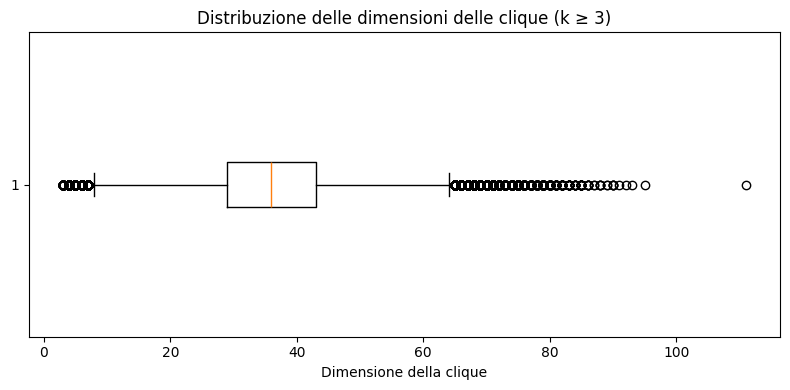

In [14]:
# Teoria Clique:
#   1) Definizione Clique: una clique è un sottografo completamente connesso: cioè un 
#      sottografo dove ogni nodo è direttamente connesso con tutti gli altri nodi.
#   2) Densità: una clique ha network_density = 1, ciò significa che tutte le possibili connessioni esistono.
# -------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------



cliques = [c for c in nx.find_cliques(hero_graph) if len(c) >= 3]
clique_sizes = pd.Series([len(c) for c in cliques])

print("Numero e dimensione delle clique (k >= 3): \n")
print(clique_sizes.describe())
print("----------------------------------------------------\n")



# Plot
plt.figure(figsize=(8, 4))
plt.boxplot(clique_sizes, vert=False)
plt.xlabel("Dimensione della clique")
plt.title("Distribuzione delle dimensioni delle clique (k ≥ 3)")
plt.tight_layout()
plt.show()

### Distribuzione delle dimensioni delle clique

Distribuzione delle dimensioni delle clique (k >= 3): 

3      106
4      210
5      316
6      555
7      882
      ... 
91       1
92       1
93       1
95       1
111      1
Name: count, Length: 93, dtype: int64
----------------------------------------------------



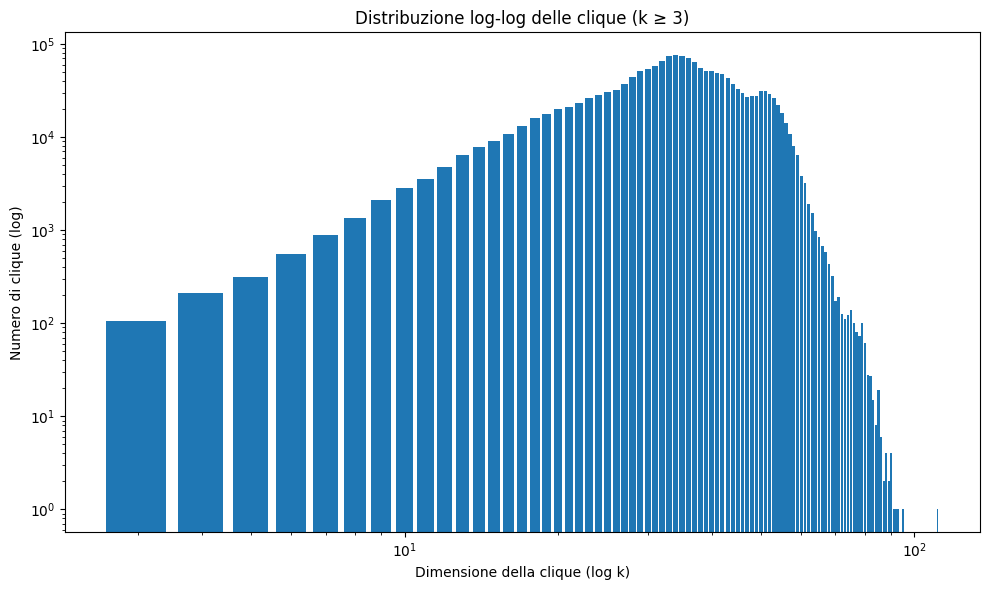

In [15]:
clique_size_dist = clique_sizes.value_counts().sort_index()

print("Distribuzione delle dimensioni delle clique (k >= 3): \n")
print(clique_size_dist)
print("----------------------------------------------------\n")



# Plot
plt.figure(figsize=(10, 6))
plt.bar(clique_size_dist.index, clique_size_dist.values)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Dimensione della clique (log k)")
plt.ylabel("Numero di clique (log)")
plt.title("Distribuzione log-log delle clique (k ≥ 3)")
plt.tight_layout()
plt.show()

### Personaggi che partecipano alle clique più grandi e Centralità basata sulle clique

Clique massime (dimensione = 111):

[['CAPTAIN AMERICA', 'IRON MAN/TONY STARK ', 'SCARLET WITCH/WANDA ', 'VISION ', 'WONDER MAN/SIMON WIL', 'WASP/JANET VAN DYNE ', 'THOR/DR. DONALD BLAK', 'HAWK', 'THING/BENJAMIN J. GR', 'MR. FANTASTIC/REED R', 'INVISIBLE WOMAN/SUE ', 'HUMAN TORCH/JOHNNY S', 'SUB-MARINER/NAMOR MA', 'SHE-HULK/JENNIFER WA', 'HULK/DR. ROBERT BRUC', 'SPIDER-MAN/PETER PAR', 'WOLVERINE/LOGAN ', 'COLOSSUS II/PETER RA', 'STORM/ORORO MUNROE S', 'CYCLOPS/SCOTT SUMMER', 'DAREDEVIL/MATT MURDO', 'BEAST/HENRY &HANK& P', 'DR. STRANGE/STEPHEN ', 'HERCULES [GREEK GOD]', 'ANGEL/WARREN KENNETH', 'QUICKSILVER/PIETRO M', 'BLACK WIDOW/NATASHA ', 'QUASAR III/WENDELL V', 'BLACK KNIGHT V/DANE ', 'CRYSTAL [INHUMAN]', 'ICEMAN/ROBERT BOBBY ', 'MOONDRAGON/HEATHER D', "BLACK PANTHER/T'CHAL", 'TIGRA/GREER NELSON', 'SERSI/SYLVIA', 'SASQUATCH/WALTER LAN', 'NORTHSTAR/JEAN-PAUL ', 'AURORA/JEANNE-MARIE ', 'SHAMAN/MICHAEL TWOYO', 'PROFESSOR X/CHARLES ', 'MOON KNIGHT/MARC SPE', 'MOCKINGBIRD/DR. BARB', 'HAVO

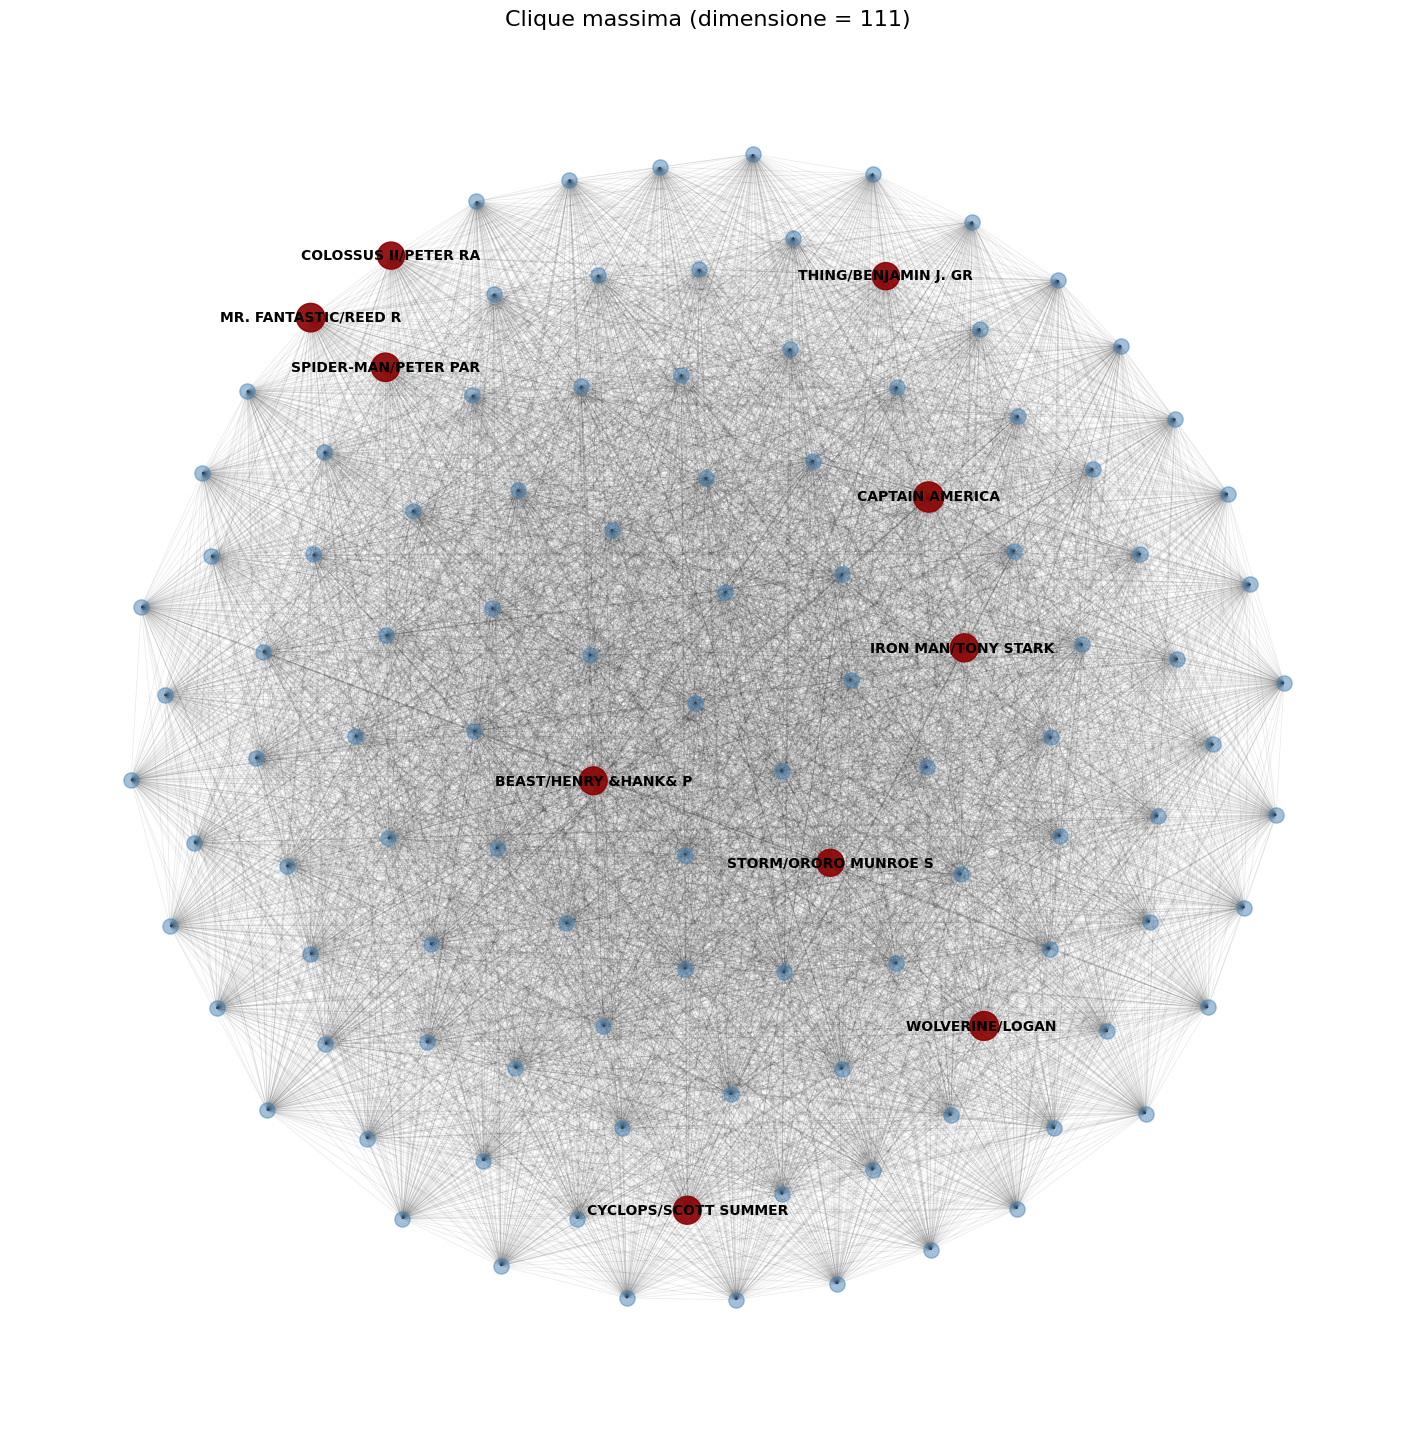

In [16]:
# 3) Personaggi che partecipano alle clique più grandi:
max_size = clique_sizes.max()
largest_cliques = [c for c in cliques if len(c) == max_size]

print(f"Clique massime (dimensione = {max_size}):\n")
print(largest_cliques)
print("----------------------------------------------------\n")




# 4) Centralità basata sulle clique
clique_participation = Counter()

for clique in cliques:
    for node in clique:
        clique_participation[node] += 1

clique_df = (pd.DataFrame.from_dict(clique_participation, orient='index', columns=['clique_count']).sort_values('clique_count', ascending=False))

print("Top 10 personaggi per partecipazione a clique (k >= 3):\n")
print(clique_df.head(10))
print("----------------------------------------------------\n")



# Plot dei punti (3)+(4)

# --- clique massima ---
largest_clique = max(cliques, key=len)
max_size = len(largest_clique)

clique_graph = hero_graph.subgraph(largest_clique)

# --- nodi top ---
top_nodes = list(clique_df.head(10).index)
top_nodes_set = set(top_nodes)

other_nodes = [n for n in clique_graph.nodes() if n not in top_nodes_set]

# dimensione nodi top proporzionale
top_sizes = clique_df.loc[top_nodes, "clique_count"].values / 3000

# --- layout ---
plt.figure(figsize=(18, 18))
pos = nx.spring_layout(clique_graph, k=1.5, iterations=50, seed=42)

# nodi di sfondo
nx.draw_networkx_nodes(clique_graph, pos, nodelist=other_nodes, node_size=120, node_color="steelblue", alpha=0.5)

# nodi top
nx.draw_networkx_nodes(clique_graph, pos, nodelist=top_nodes, node_size=top_sizes, node_color="darkred", alpha=0.9)

# etichette solo top
nx.draw_networkx_labels(clique_graph, pos, labels={n: n for n in top_nodes}, font_size=10, font_weight="bold")

# archi
nx.draw_networkx_edges(clique_graph, pos, alpha=0.08, width=0.6)

plt.title(f"Clique massima (dimensione = {max_size})", fontsize=16)
plt.axis("off")
plt.show()

### Clique vs degree distribution
Idea chiave:
1. Degree (misura locale): quante connessioni dirette ha un nodo --> misura la popolarità
2. Clique (misura strutturale): in quanti sottogruppi completamente connessi è immerso un nodo --> misura l'integrazione sociale.
3. Dunque: due nodi possono avere degree simile ma ruoli strutturali completamente diversi, cioè:
   1. zona in basso a sinistra: sono i nodi marginali, cioè nodi con poche connessioni, poche clique.
   2. degree alto + clique alte: sono i veri hub sociali, cioè personaggi centrali nella narrazione (Captain America, Spider-Man…)
   3. degree alto + clique basse: sono i broker/ponti tra comunità

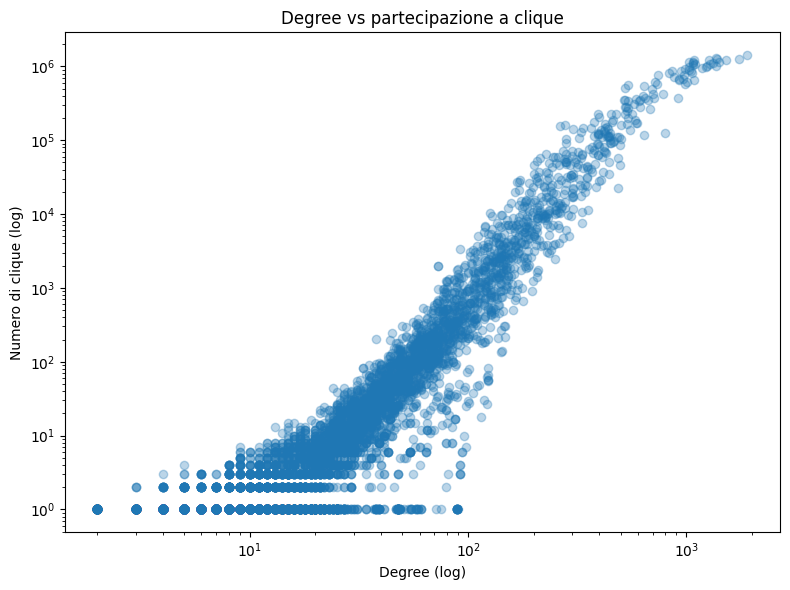

In [19]:
degree_dict = dict(hero_graph.degree())
degree_series = pd.Series(degree_dict)
analysis_df = pd.DataFrame({"degree": degree_series, "clique_count": clique_df["clique_count"]}).dropna()



# Plot
plt.figure(figsize=(8, 6))
plt.scatter(analysis_df["degree"], analysis_df["clique_count"], alpha=0.3)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Degree (log)")
plt.ylabel("Numero di clique (log)")
plt.title("Degree vs partecipazione a clique")

plt.tight_layout()
plt.show()

### triadi chiuse vs partecipazione a clique:
Usiamo:
1. $triads\_count$: triadi chiuse per nodo.
2. $clique\_df["clique\_count"]$: partecipazione a clique
3. Concetto: chi ha molte triadi chiuse tende a comparire in molte clique

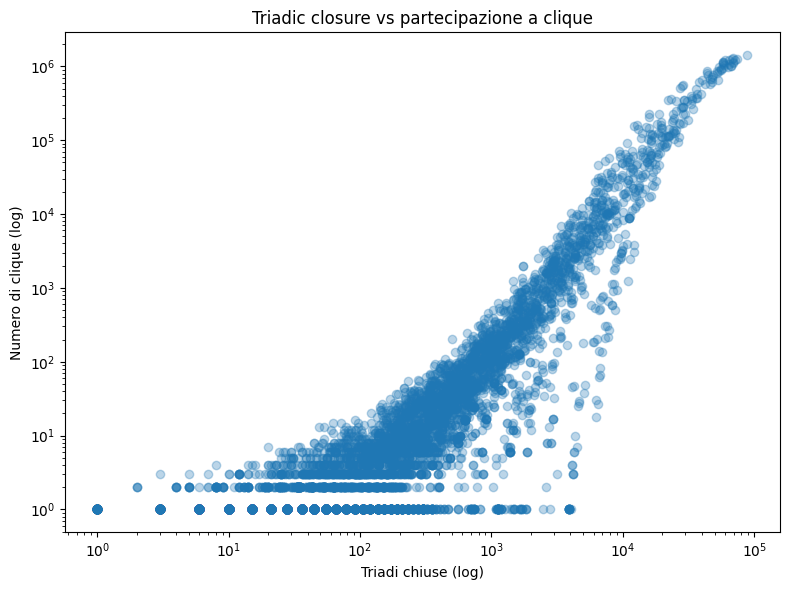

In [24]:
triad_clique_df = pd.DataFrame({"closed_triads": triads_count, "clique_count": clique_df["clique_count"]}).dropna()



# Plot
plt.figure(figsize=(8, 6))
plt.scatter(triad_clique_df["closed_triads"], triad_clique_df["clique_count"], alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Triadi chiuse (log)")
plt.ylabel("Numero di clique (log)")
plt.title("Triadic closure vs partecipazione a clique")
plt.tight_layout()
plt.show()